In [6]:
#importing data
import pandas as pd
df = pd.read_csv("TCGA.BRCA.sampleMap_HiSeqV2.gz", sep="\t", compression="gzip", index_col=0)

print(df.head())

           TCGA-AR-A5QQ-01  TCGA-D8-A1JA-01  TCGA-BH-A0BQ-01  TCGA-BH-A0BT-01  \
sample                                                                          
ARHGEF10L           9.5074           7.4346           9.3216           9.0198   
HIF3A               1.5787           3.6607           2.7224           1.3414   
RNF17               0.0000           0.6245           0.5526           0.0000   
RNF10              11.3676          11.9181          11.9665          13.1881   
RNF11              11.1292          13.5273          11.4105          11.0911   

           TCGA-A8-A06X-01  TCGA-A8-A096-01  TCGA-BH-A0C7-01  TCGA-AC-A5XU-01  \
sample                                                                          
ARHGEF10L           9.6417           9.7665          10.0931           9.1524   
HIF3A               0.5819           0.2738           3.6090           0.4738   
RNF17               0.0000           0.8765           0.0000           0.0000   
RNF10              12.0036 

In [8]:
#checking file read properly
df.head()
df.shape

df.head()
df.iloc[:5, :5]

,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01
sample,,,,,
ARHGEF10L,9.5074,7.4346,9.3216,9.0198,9.6417
HIF3A,1.5787,3.6607,2.7224,1.3414,0.5819
RNF17,0.0000,0.6245,0.5526,0.0000,0.0000
RNF10,11.3676,11.9181,11.9665,13.1881,12.0036
RNF11,11.1292,13.5273,11.4105,11.0911,11.2545


In [12]:
#defining tumor v.s normal groups
tumor_samples = [col for col in df.columns if col.endswith("-01")]
normal_samples = [col for col in df.columns if col.endswith("-11")]

print(len(tumor_samples), len(normal_samples))

tumor = df[tumor_samples]
normal = df[normal_samples]

1097 114


In [30]:
#core analysis
import numpy as np
from scipy.stats import ttest_ind
results = []

for gene in df.index:
    t_vals = tumor.loc[gene]
    n_vals = normal.loc[gene]
    stat, pval = ttest_ind(t_vals, n_vals, equal_var=False)
    log2fc = np.log2(t_vals.mean() + 1) - np.log2(n_vals.mean() + 1)
    results.append([gene, log2fc, pval])
res = pd.DataFrame(results, columns=["gene", "log2FC", "pval"])

#correcting for multiple testing
from statsmodels.stats.multitest import multipletests
res["adj_pval"] = multipletests(res["pval"], method="fdr_bh")[1]

print("df exists:", "df" in globals())
print("res exists:", "res" in globals())

df exists: True
res exists: True


In [34]:
#y my volcano plot blank
print(res["pval"].isna().sum())
print(res["pval"].dtype)
print(res["pval"].head())

res = res.dropna(subset=["pval"])
res["pval"] = res["pval"].astype(float)

from statsmodels.stats.multitest import multipletests
res["adj_pval"] = multipletests(res["pval"].values, method="fdr_bh")[1]

print(res["adj_pval"].isna().sum())
print(res["adj_pval"].describe())

0
float64
0    7.371801e-05
1    1.059201e-97
2    1.613438e-02
3    7.693040e-06
4    6.506945e-26
Name: pval, dtype: float64
0
count     2.025000e+04
mean      7.564365e-02
std       1.999584e-01
min      6.888953e-226
25%       2.005264e-26
50%       1.380722e-10
75%       4.552028e-03
max       9.998313e-01
Name: adj_pval, dtype: float64


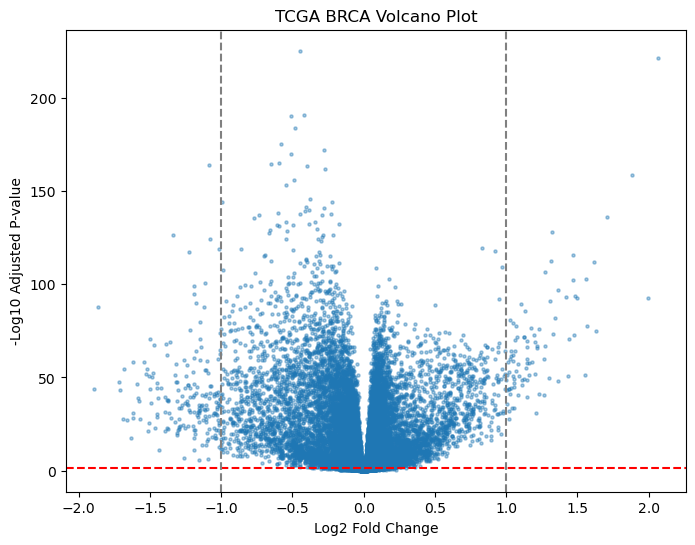

In [35]:
#volcano plot
import matplotlib.pyplot as plt
import numpy as np

pvals = res["adj_pval"].replace(0, 1e-300) # avoid log(0)

x = res["log2FC"]
y = -np.log10(pvals)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.4, s=5)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("TCGA BRCA Volcano Plot")
plt.axhline(-np.log10(0.05), color='red', linestyle='--')
plt.axvline(1, color='grey', linestyle='--')
plt.axvline(-1, color='grey', linestyle='--')

plt.show()

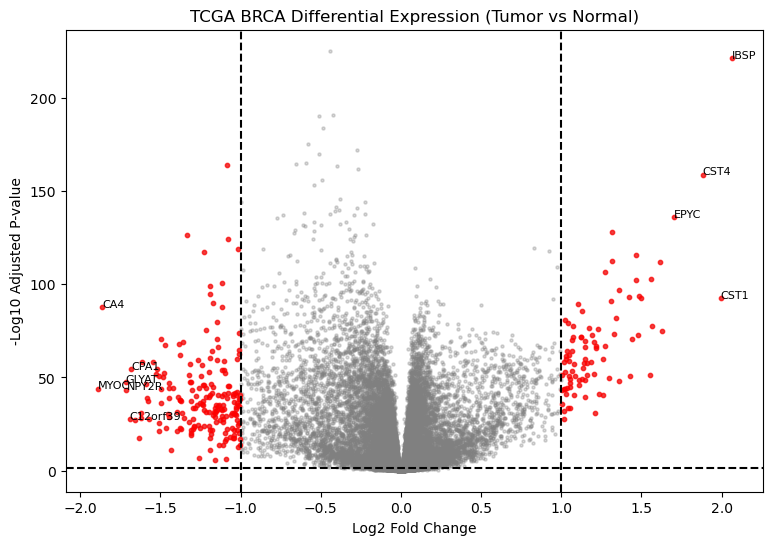

In [36]:
#highlighting top genes
sig = res[(res["adj_pval"] < 0.05) & (abs(res["log2FC"]) > 1)].copy()
top_labeled = sig.reindex(
    (abs(sig["log2FC"])).sort_values(ascending=False).index
).head(10)

plt.figure(figsize=(9,6))

# all genes (gray)
plt.scatter(res["log2FC"], -np.log10(res["adj_pval"].replace(0, 1e-300)),
            alpha=0.3, s=5, color="gray")

# significant genes (red)
plt.scatter(sig["log2FC"], -np.log10(sig["adj_pval"].replace(0, 1e-300)),
            alpha=0.7, s=10, color="red")

# label top genes
for _, row in top_labeled.iterrows():
    plt.text(row["log2FC"],
             -np.log10(row["adj_pval"]),
             row["gene"],
             fontsize=8)

plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("TCGA BRCA Differential Expression (Tumor vs Normal)")

plt.show()

In [40]:
#pca and clustering analysis
df_t = df.T

labels = ["Tumor" if x.endswith("-0.1") else "Normal" for x in df_t.index]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(df_t) # scale data

pca = PCA(n_components=2) # PCA to 2D
components = pca.fit_transform(X_scaled)

import pandas as pd

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["label"] = labels

In [41]:
#labelling logic
from collections import Counter
print(Counter([x[-3:] for x in df_t.index]))

labels = []

for x in df_t.index:
    code = x.split("-")[-1]
    if code == "01":
        labels.append("Tumor")
    elif code == "11":
        labels.append("Normal")
    else:
        labels.append("Other")

import pandas as pd

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["label"] = labels
pca_df = pca_df[pca_df["label"] != "Other"]

Counter({'-01': 1097, '-11': 114, '-06': 7})


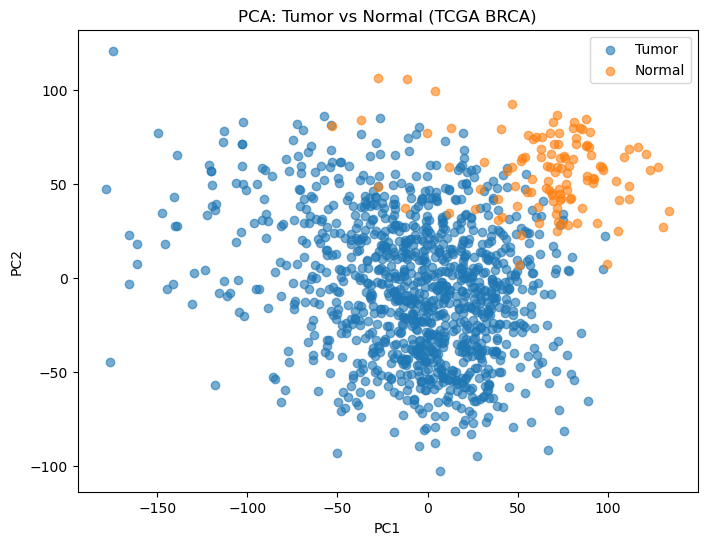

In [47]:
#plotting pca
import matplotlib.pyplot as plt

colors = {"Tumor": "blue", "Normal": "orange"}

plt.figure(figsize=(8,6))

for label in pca_df["label"].unique():
    subset = pca_df[pca_df["label"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Tumor vs Normal (TCGA BRCA)")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

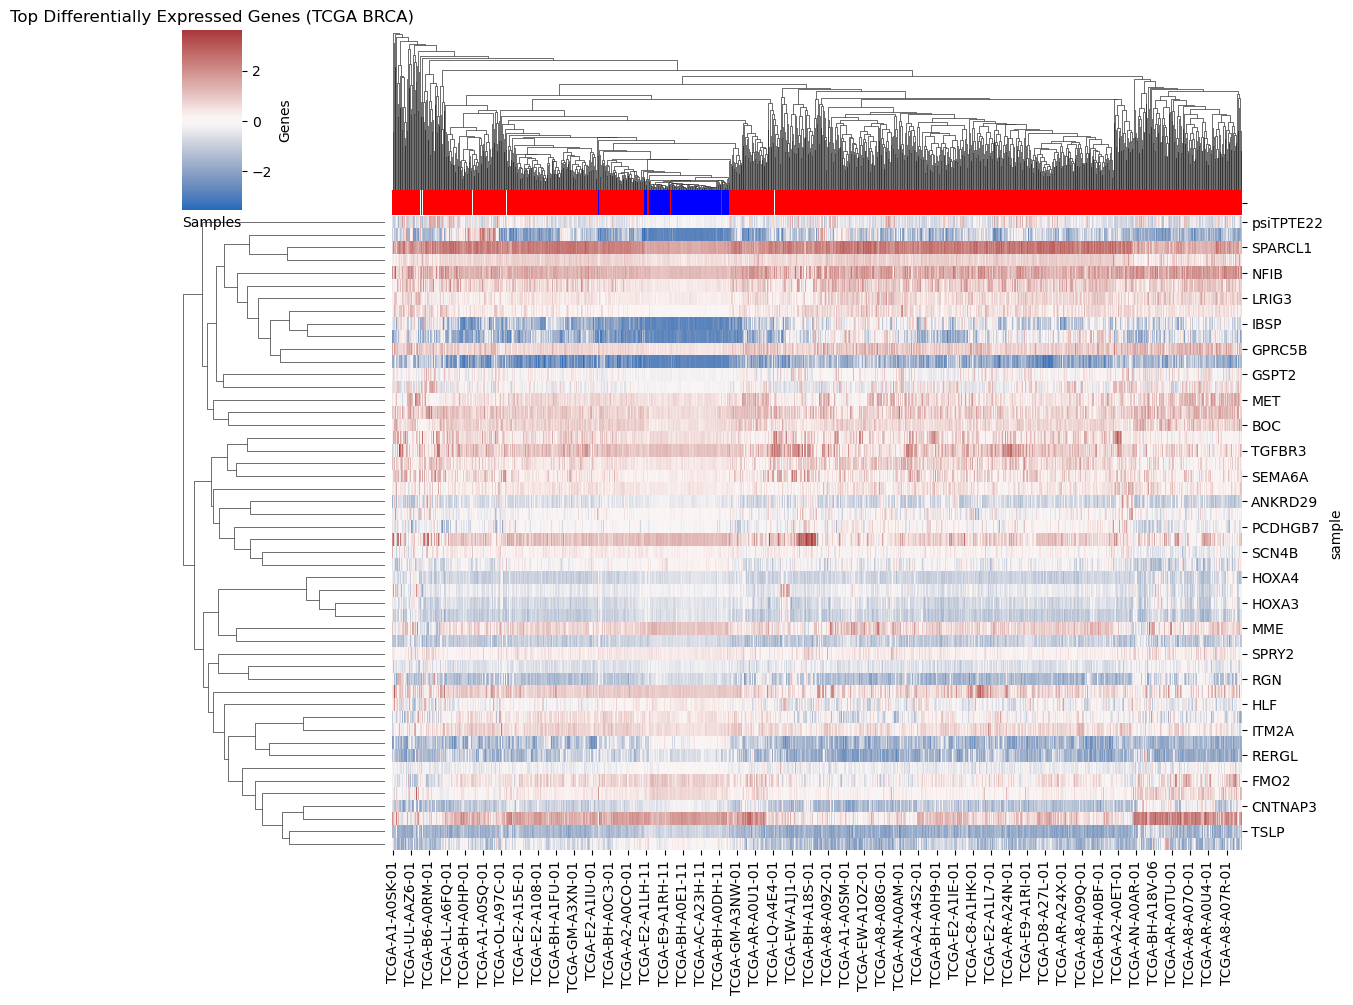

In [51]:
#heatmapping top genes
top_genes = res.sort_values("adj_pval").head(50)["gene"]
heatmap_data = df.loc[top_genes]

#scaling genes
from sklearn.preprocessing import StandardScaler

heatmap_scaled = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

import pandas as pd

sample_labels = pd.Series(labels, index=df_t.index)
sample_labels = sample_labels.loc[heatmap_scaled.columns]

#plotting heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

col_colors = sample_labels.map({"Tumor": "red", "Normal": "blue"})
sns.clustermap(
    heatmap_scaled,
    cmap="vlag",
    col_colors=col_colors,
    figsize=(12,10),
    metric="correlation",
    method="average"
)

plt.title("Top Differentially Expressed Genes (TCGA BRCA)")
plt.ylabel("Genes")
plt.xlabel("Samples")

plt.show()